In [1]:
using CSV, DataFrames
using MonotonicSplines
using Interpolations
using CairoMakie
using DataStructures
using Distributions
using DensityInterface
using BAT
using LaTeXStrings
using Accessors
using StatsBase
using Printf
using Newtrinos


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x6ac67bf391afc512, 0xfabc5de86803236c, 0x5d65ca6d6af05fec, 0x73b6456db36da83e, 0x58ebd589733375c4, 0x6738fb913b9bd8e3, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), ADTypes.NoAutoDiff())
[ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0x6ac67bf391afc512, 0xfabc5de86803236c, 0x5d65ca6d6af05fec, 0x73b6456db36da83e, 0x58ebd589733375c4, 0x6738fb913b9bd8e3, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())


In [5]:
@kwdef struct SuperKAtm <: Newtrinos.Experiment
    physics::NamedTuple
    params::NamedTuple
    priors::NamedTuple
    assets::NamedTuple
    forward_model::Function
    plot::Function
end

SuperKAtm

In [6]:
function configure(physics)
    physics = (;physics.osc, physics.atm_flux, physics.earth_layers, physics.xsec)
    assets = get_assets(physics)
    return SuperKAtm(
        physics = physics,
        params = get_params(),
        priors = get_priors(),
        assets = assets,
        forward_model = get_forward_model(physics, assets),
        plot = get_plot(physics, assets)
    )
end

configure (generic function with 1 method)

In [7]:
function read_sk_file(filepath::String)
    df = CSV.read(filepath, DataFrame; delim=' ', ignorerepeated=true, comment="#", header=false)
    rename!(df, [
        :Counts, :EnergyAvg, :EnergyRMS, :EnergyQuantile2_3Percent, :EnergyQuantile15_9Percent,
        :EnergyQuantile50_0Percent, :EnergyQuantile84_1Percent, :EnergyQuantile97_7Percent,
        :CosZAvg, :CosZRMS, :CosZQuantile2_3Percent, :CosZQuantile15_9Percent,
        :CosZQuantile50_0Percent, :CosZQuantile84_1Percent, :CosZQuantile97_7Percent
    ])
    return df
end

read_sk_file (generic function with 1 method)

In [8]:
function make_log_e_cdf(bin)
    log_e = log10.([bin.EnergyQuantile2_3Percent, bin.EnergyQuantile15_9Percent, bin.EnergyQuantile50_0Percent, bin.EnergyQuantile84_1Percent, bin.EnergyQuantile97_7Percent])  # extrapolate tails

    log_energy_quantiles = [2*log_e[1] - log_e[2], log_e... , 2*log_e[end] - log_e[end-1]]  # extrapolate tails 
    #log_energy_quantiles = [log_e[1] - mean(diff(log_e)), log_e... , log_e[end] + mean(diff(log_e))]  # extrapolate tails 
    quantile_probs = [0.0, 0.023, 0.159, 0.5, 0.841, 0.977, 1.]  # corresponding probabilities

    dy_dx = MonotonicSplines.estimate_dYdX(log_energy_quantiles, quantile_probs)
    dy_dx[1] = 0
    dy_dx[end] = 0
    f = RQSpline(log_energy_quantiles, quantile_probs, dy_dx)


    f_save = x -> begin
        if x < log_energy_quantiles[1]
            return 0.0
        elseif x > log_energy_quantiles[end]
            return 1.0
        else
            return f(x)
        end
    end

    return f_save
end


make_log_e_cdf (generic function with 1 method)

In [9]:
function make_cosz_cdf(bin)
    cosz = [bin.CosZQuantile2_3Percent, bin.CosZQuantile15_9Percent, bin.CosZQuantile50_0Percent, bin.CosZQuantile84_1Percent, bin.CosZQuantile97_7Percent]  # extrapolate tails

    cosz_quantiles = [-1, cosz..., 1]  # extrapolate tails 
    cosz_quantiles = [min(-1, 2*cosz[1] - cosz[2]), cosz... , max(1, 2*cosz[end] - cosz[end-1])]  # extrapolate tails 
    quantile_probs = [0., 0.023, 0.159, 0.5, 0.841, 0.977, 1.]  # corresponding probabilities

    dy_dx = MonotonicSplines.estimate_dYdX(cosz_quantiles, quantile_probs)
    #dy_dx[1] = 0
    #dy_dx[end] = 0
    f = RQSpline(cosz_quantiles, quantile_probs, dy_dx)
    f_save = x -> begin
        if x <= cosz_quantiles[1]
            return 0.0
        elseif x > cosz_quantiles[end]
            return 1.0
        else
            return f(x)
        end
    end

    return f_save
end

make_cosz_cdf (generic function with 1 method)

In [139]:
function make_response_matrix(MC_component, logE_grid, cosZ_grid)
    n_bins = size(MC_component, 1)
    n_logE = length(logE_grid)
    n_cosZ = length(cosZ_grid)

    response_matrix = zeros(Float32, n_bins, n_logE-1, n_cosZ-1)

    for bin_idx in 1:n_bins
        bin = MC_component[bin_idx, :]

        if bin.Counts == 0
            continue
        end

        log_e_cdf = make_log_e_cdf(bin)
        cosz_cdf = make_cosz_cdf(bin)

        c_e = log_e_cdf.(logE_grid)
        p_e = diff(c_e)

        c_cosz = cosz_cdf.(cosZ_grid)
        p_cosz = diff(c_cosz)

        response_matrix[bin_idx, :, :] .= p_e * p_cosz'

        # for logE_idx in 1:(n_logE-1)
        #     e_low = logE_grid[logE_idx]
        #     e_high = logE_grid[logE_idx+1]
        #     p_e = (log_e_cdf(e_high) - log_e_cdf(e_low))

        #     for cosZ_idx in 1:(n_cosZ-1)
        #         cosz_low = cosZ_grid[cosZ_idx]
        #         cosz_high = cosZ_grid[cosZ_idx+1]
        #         p_cosz = cosz_cdf(cosz_high) - cosz_cdf(cosz_low)

        #         response_matrix[bin_idx, logE_idx, cosZ_idx] = p_e * p_cosz
        #     end
        # end
        sum_response = sum(response_matrix[bin_idx, :, :])
        if sum_response == 0
            continue
        end
        response_matrix[bin_idx, :, :] .= response_matrix[bin_idx, :, :] ./ sum_response #* bin.Counts
    end
    return response_matrix
end

make_response_matrix (generic function with 1 method)

In [175]:
function calc_weights(params, assets, physics)

    E = 10. .^midpoints(assets.loge_grid)

    p = physics.osc.osc_prob(E, assets.paths, assets.layers, params);
    p_anti = physics.osc.osc_prob(E, assets.paths, assets.layers, params, anti=true);

    flux = physics.atm_flux.sys_flux(assets.flux_nominal, params)
    #R = NamedTuple(key => assets.R[key] .+ ((params.sk_energy_scale - 1.0)/0.02 .* assets.delta_R[key]) for key in keys(assets.R))

    s = (size(p)[1], size(p)[2])

    p_flux(out) = reshape(reshape(flux.nue, s) .* p[:, :, 1, out] .+ reshape(flux.numu, s) .* p[:, :, 2, out], 1, s...)
    p_flux_anti(out) = reshape(reshape(flux.nuebar, s) .* p_anti[:, :, 1, out] .+ reshape(flux.numubar, s) .* p_anti[:, :, 2, out], 1, s...)

    nue = sum((assets.R.nue .+ ((params.sk_energy_scale - 1.0)/0.02 .* assets.delta_R.nue)).* p_flux(1) .* reshape(physics.xsec.scale(E, :nue, :CC, false, params), (1, :, 1)), dims=(2,3))
    numu = sum((assets.R.numu .+ ((params.sk_energy_scale - 1.0)/0.02 .* assets.delta_R.numu)) .* p_flux(2) .* reshape(physics.xsec.scale(E, :numu, :CC, false, params), (1, :, 1)), dims=(2,3))
    nutau = sum((assets.R.nutau .+ ((params.sk_energy_scale - 1.0)/0.02 .* assets.delta_R.nutau)) .* (p_flux(3).* reshape(physics.xsec.scale(E, :nutau, :CC, false, params), (1, :, 1)) .+ p_flux_anti(3).* reshape(physics.xsec.scale(E, :nutau, :CC, true, params), (1, :, 1))), dims=(2,3))
    nuebar = sum((assets.R.nuebar .+ ((params.sk_energy_scale - 1.0)/0.02 .* assets.delta_R.nuebar)) .* p_flux_anti(1).* reshape(physics.xsec.scale(E, :nuebar, :CC, true, params), (1, :, 1)), dims=(2,3))
    numubar = sum((assets.R.numubar .+ ((params.sk_energy_scale - 1.0)/0.02 .* assets.delta_R.numubar)) .* p_flux_anti(2).* reshape(physics.xsec.scale(E, :numubar, :CC, true, params), (1, :, 1)), dims=(2,3))
    nunc = sum((assets.R.nunc .+ ((params.sk_energy_scale - 1.0)/0.02 .* assets.delta_R.nunc)) .* physics.xsec.scale(E, :nunc, :NC, false, params), dims=(2,3))

    return (; nue, numu, nutau, nuebar, numubar, nunc)
end

calc_weights (generic function with 1 method)

In [140]:
function get_assets(physics; datadir = @__DIR__)
    @info "Loading Super-K Data"

    bininfo = CSV.read(joinpath(datadir, "bins/sk_2023_BinInfo.txt"), DataFrame; delim=' ', ignorerepeated=true, comment="#", header=false);
    rename!(bininfo, [:Sample, :logPMin, :logPMax, :CosZMin, :CosZMax]);
    bad_entries = findall(bininfo.CosZMin .> bininfo.CosZMax)

    bininfo[bad_entries[1], :].CosZMax = 0.0
    bininfo[bad_entries[2], :].CosZMax = 0.0
    bininfo[bad_entries[3], :].CosZMax = 1.0    

    masks = (
        fc = occursin.("_fc_", bininfo.Sample),
        pc = occursin.("_pc_", bininfo.Sample),
        upmu = occursin.("_upmu_", bininfo.Sample),
        pc_stop = occursin.("_pc_stop", bininfo.Sample),
        pc_thru = occursin.("_pc_thru", bininfo.Sample),
        umpmu_stop = occursin.("_upmu_stop", bininfo.Sample),
        upmu_thru = occursin.("_upmu_thru", bininfo.Sample),
        upmu_shower = occursin.(r"_upmu_.*_showering",  bininfo.Sample),
        upmu_nonshower = occursin.(r"_upmu_.*_nonshowering", bininfo.Sample),
        mu_indices = occursin.("_numu", bininfo.Sample),
        sk_i_iii_elike_0decay_e = occursin.(r"sk1-3_.*elike_0decaye", bininfo.Sample),
        sk_i_iii_elike_1decay_e = occursin.(r"sk1-3_.*elike_1decaye", bininfo.Sample),
        sk_i_iii_mulike_0decay_e = occursin.(r"sk1-3_.*mulike_0decaye", bininfo.Sample),
        sk_i_iii_mulike_1decay_e = occursin.(r"sk1-3_.*mulike_1decaye", bininfo.Sample),
        sk_i_iii_mulike_2decay_e = occursin.(r"sk1-3_.*mulike_2decaye", bininfo.Sample),
        sk_iv_v_0decay_e = occursin.(r"sk4-5_fc_.*_nuebarlike",  bininfo.Sample),
        sk_iv_v_1decay_e = occursin.(r"sk4-5_fc_.*_nuelike",  bininfo.Sample),
        sk_iv_v_subgev_0neutron = occursin.(r"sk4-5_fc_subgev.*(_0neutron|numulike)", bininfo.Sample),
        sk_iv_v_subgev_1neutron = occursin.(r"sk4-5_fc_subgev.*(_1neutron|numubarlike)", bininfo.Sample),
        sk_iv_v_multigev_0neutron = occursin.(r"sk4-5_fc_multigev.*(_0neutron|numulike)", bininfo.Sample),
        sk_iv_v_multigev_1neutron = occursin.(r"sk4-5_fc_multigev.*(_1neutron|numubarlike)", bininfo.Sample),
        sk_i_v_multigev_multiring_nue = occursin.("sk1-5_fc_multigev_multiring_nuelike", bininfo.Sample),
        sk_i_v_multigev_multiring_nuebar = occursin.("sk1-5_fc_multigev_multiring_nuebarlike", bininfo.Sample),
        sk_i_v_multigev_multiring_mu = occursin.("sk1-5_fc_multigev_multiring_mulike", bininfo.Sample),
        sk_i_v_multigev_multiring_other = occursin.("sk1-5_fc_multigev_multiring_other", bininfo.Sample),
    )

    data = CSV.read(joinpath(datadir, "bins/sk_2023_Data.txt"), DataFrame; delim=' ', ignorerepeated=true, comment="#", header=false)
    observed = round.(data.Column1);

    MC = (nue=read_sk_file(joinpath(datadir, "bins/normal/sk_2023_MCNueNO.txt")),
        numu=read_sk_file(joinpath(datadir, "bins/normal/sk_2023_MCNumuNO.txt")),
        nutau=read_sk_file(joinpath(datadir, "bins/normal/sk_2023_MCNutauNO.txt")),
        nuebar=read_sk_file(joinpath(datadir, "bins/normal/sk_2023_MCNueBarNO.txt")),
        numubar=read_sk_file(joinpath(datadir, "bins/normal/sk_2023_MCNumuBarNO.txt")),
        nunc=read_sk_file(joinpath(datadir, "bins/normal/sk_2023_MCNCNO.txt")))

        
    loge_grid = LinRange(-1,3,201)
    cz_grid = LinRange(-1.0,1.0,101)

    R = NamedTuple(key => make_response_matrix(MC[key], loge_grid, cz_grid) for key in keys(MC))
    R_plus = NamedTuple(key => make_response_matrix(MC[key], loge_grid .+ log(1.02), cz_grid) for key in keys(MC))
    R_minus = NamedTuple(key => make_response_matrix(MC[key], loge_grid .+ log(0.98), cz_grid) for key in keys(MC))
    delta_R = NamedTuple(key => (R_plus[key] .- R_minus[key])./2 for key in keys(MC))

    # Bestfit from SK atm 2023 paper
    params_nominal = Newtrinos.get_params(physics)
    @reset params_nominal.Δm²₃₁ = 2.475e-3
    @reset params_nominal.θ₂₃ = asin(sqrt(0.45))
    @reset params_nominal.θ₁₃ = asin(sqrt(0.02))
    @reset params_nominal.δCP = -1.89

    layers = physics.earth_layers.compute_layers()
    paths = physics.earth_layers.compute_paths(midpoints(cz_grid), layers)

    flux_nominal = physics.atm_flux.nominal_flux(10. .^midpoints(loge_grid), midpoints(cz_grid))

    
    nominal_weights = calc_weights(merge(params_nominal, (sk_energy_scale=1.0,)), (;R, delta_R, flux_nominal, paths, layers, loge_grid), physics)

    return (; MC, R, delta_R, R_plus, R_minus, flux_nominal, paths, layers, loge_grid, cz_grid, nominal_weights, observed, bininfo, masks)

end


get_assets (generic function with 1 method)

In [113]:
    
function get_params()
    params = (
        sk_energy_scale = 1.0,
        sk_fc_norm = 1.0,
        sk_pc_norm = 1.0,
        sk_upmu_norm = 1.0,
        sk_fiducial_norm = 1.0,
        sk_nc_mu_norm = 1.0,
        sk_pc_stopping_vs_througoing = 1.0,
        sk_upmu_stopping_vs_througoing = 1.0,
        sk_upmu_nonshower_vs_shower = 1.0,
        sk_i_iii_decay_e_tag_eff = 1.0,
        sk_iv_v_decay_e_tag_eff = 1.0,
        sk_iv_v_subgev_neutron_tag_eff = 1.0,
        sk_iv_v_multigev_neutron_tag_eff = 1.0,
        sk_i_v_btd_1 = 1.0,
        sk_i_v_btd_2 = 1.0,
        sk_i_v_btd_3 = 1.0,
        )
end

function get_priors()
    priors = (
        sk_energy_scale = Normal(1.0, 0.02),
        sk_fc_norm = Normal(1.0, 0.05),
        sk_pc_norm = Normal(1.0, 0.05),
        sk_upmu_norm = Normal(1.0, 0.05),
        sk_fiducial_norm = Normal(1.0, 0.02),
        sk_nc_mu_norm = Normal(1.0, 0.1),
        sk_pc_stopping_vs_througoing = Normal(1.0, 0.2),
        sk_upmu_stopping_vs_througoing = Normal(1.0, 0.01),
        sk_upmu_nonshower_vs_shower = Normal(1.0, 0.04),
        sk_i_iii_decay_e_tag_eff = Normal(1.0, 0.015),
        sk_iv_v_decay_e_tag_eff = Normal(1.0, 0.008),
        sk_iv_v_subgev_neutron_tag_eff = Normal(1.0, 0.12),
        sk_iv_v_multigev_neutron_tag_eff = Normal(1.0, 0.12),
        sk_i_v_btd_1 = Normal(1, 0.05),
        sk_i_v_btd_2 = Normal(1, 0.05),
        sk_i_v_btd_3 = Normal(1, 0.05),
        )
end


get_priors (generic function with 1 method)

In [114]:
safe_div(a, b) = b == 0 ? 1.0 : a / b

safe_div (generic function with 1 method)

In [115]:
function reweight(params, physics, assets)
    weights = calc_weights(params, assets, physics)
    return NamedTuple(key => assets.MC[key].Counts .* safe_div.(vec(weights[key]), vec(assets.nominal_weights[key])) for key in keys(assets.MC))
end

reweight (generic function with 1 method)

In [116]:
function get_factor(mask, factor)
    mask * factor .+ .!mask 
end

function get_double_factor(total, mask1, mask2, factor1)
    total1 = sum(total[mask1])
    total2 = sum(total[mask2])
    new_total1 = factor1 * total1
    new_total2 = total2 + total1 - new_total1
    factor2 = new_total2 / total2

    factor = (mask1 * factor1 .+ .!mask1) .* (mask2 * factor2 .+ .!mask2)

    return factor
end

function get_all_factors(params, assets, total)
    return (
        get_factor(assets.masks.fc, params.sk_fc_norm * params.sk_fiducial_norm) .*
        get_factor(assets.masks.pc, params.sk_pc_norm * params.sk_fiducial_norm) .*
        get_factor(assets.masks.upmu, params.sk_upmu_norm) .*
        get_double_factor(total, assets.masks.pc_stop, assets.masks.pc_thru, params.sk_pc_stopping_vs_througoing) .*
        get_double_factor(total, assets.masks.umpmu_stop, assets.masks.upmu_thru, params.sk_upmu_stopping_vs_througoing) .*
        get_double_factor(total, assets.masks.upmu_nonshower, assets.masks.upmu_shower, params.sk_upmu_nonshower_vs_shower) .* 
        get_double_factor(total, assets.masks.sk_i_iii_elike_1decay_e, assets.masks.sk_i_iii_elike_0decay_e, params.sk_i_iii_decay_e_tag_eff) .*
        get_double_factor(total, assets.masks.sk_i_iii_mulike_1decay_e, assets.masks.sk_i_iii_mulike_0decay_e, params.sk_i_iii_decay_e_tag_eff) .*
        get_double_factor(total, assets.masks.sk_i_iii_mulike_2decay_e, assets.masks.sk_i_iii_mulike_1decay_e, params.sk_i_iii_decay_e_tag_eff) .*
        get_double_factor(total, assets.masks.sk_iv_v_1decay_e, assets.masks.sk_iv_v_0decay_e, params.sk_iv_v_decay_e_tag_eff) .*
        get_double_factor(total, assets.masks.sk_iv_v_subgev_0neutron, assets.masks.sk_iv_v_subgev_1neutron, params.sk_iv_v_subgev_neutron_tag_eff) .*
        get_double_factor(total, assets.masks.sk_iv_v_multigev_0neutron, assets.masks.sk_iv_v_multigev_1neutron, params.sk_iv_v_multigev_neutron_tag_eff) .*
        get_double_factor(total, assets.masks.sk_i_v_multigev_multiring_nuebar, assets.masks.sk_i_v_multigev_multiring_nue, params.sk_i_v_btd_1) .*
        get_double_factor(total, assets.masks.sk_i_v_multigev_multiring_nue, assets.masks.sk_i_v_multigev_multiring_mu, params.sk_i_v_btd_2) .*
        get_double_factor(total, assets.masks.sk_i_v_multigev_multiring_mu, assets.masks.sk_i_v_multigev_multiring_other, params.sk_i_v_btd_3)
    )
end

get_all_factors (generic function with 1 method)

In [117]:
function get_expected(params, physics, assets)
    expected = reweight(params, physics, assets)

    total = sum([expected[key] for key in keys(expected)])

    factors = get_all_factors(params, assets, total)

    nunc = expected.nunc .* factors .* get_factor(assets.masks.mu_indices, params.sk_nc_mu_norm) #* params.nc_norm 
    
    nue = expected.nue .* factors
    numu = expected.numu .* factors
    nutau = expected.nutau .* factors #.* params.nutau_cc_norm
    nuebar = expected.nuebar .* factors
    numubar = expected.numubar .* factors

    return (; nue, numu, nutau, nuebar, numubar, nunc)
end

get_expected (generic function with 1 method)

In [118]:
function get_forward_model(physics, assets)
    function fwd_model(params)
        expected = get_expected(params, physics, assets)
        total = sum(expected[key] for key in keys(expected))
        clamped = max.(1e-3, total)
        distprod(Poisson.(clamped))
    end
end

get_forward_model (generic function with 1 method)

In [119]:
function format_plot_title(raw::String)
    # Replace underscores with spaces
    title = replace(raw, "_" => " ")

    # Replace known abbreviations with readable forms
    replacements = Dict(
        "fc" => "FC",
        "pc" => "PC",
        "subgev" => "Sub-GeV",
        "multigev" => "Multi-GeV",
        "1ring" => "1-Ring",
        "decaye" => "Decay-e",
        "sk1-3" => "SKI-III",
        "sk1-5" => "SKI-V",
        "sk4-5" => "SKIV-V",
        "nuelike" => "νe-like",
        "nuebarlike" => "νe-bar-like",
        "numubarlike" => "‾νμ-bar-like",
        "numulike" => "νμ-like",
    )

    for (key, val) in replacements
        title = replace(title, key => val)
    end

    # Capitalize first letter of each word
    #title = join(uppercasefirst.(split(title)), " ")

    return title
end

format_plot_title (generic function with 1 method)

In [120]:
plot_order = [:nunc, :numubar, :nuebar, :nutau, :numu, :nue]
plot_color = Dict(zip(plot_order, [:gray80, :paleturquoise, :lightpink, :purple, :steelblue3, :red3]))
plot_labels = Dict(zip(plot_order, [L"NC", L"$\bar{\nu}_\mu$", L"$\bar{\nu}_e$", L"$\nu_\tau$", L"$\nu_\mu$", L"$\nu_e$"]))

Dict{Symbol, LaTeXString} with 6 entries:
  :numubar => L"$\bar{\nu}_\mu$"
  :numu    => L"$\nu_\mu$"
  :nuebar  => L"$\bar{\nu}_e$"
  :nutau   => L"$\nu_\tau$"
  :nue     => L"$\nu_e$"
  :nunc    => L"$NC$"

In [121]:
function get_plot(physics, assets)

    function plot(params, data=assets.observed)

        bininfo = assets.bininfo
        expected = get_expected(params, physics, assets)

        fig = Figure()
        for (i,sample) in enumerate(unique(bininfo.Sample))
            grid_idx = (Int(floor((i-1)/5))+1, (i-1)%5+1)
            inds = findall(bininfo.Sample .== sample)
            e = NamedTuple(key => expected[key][inds] for key in keys(expected))
            o = data[inds]
            ax = Axis(fig[grid_idx...]; title=format_plot_title(sample), width = 200, height = 150, titlesize=10)
            if all(bininfo.CosZMin[inds] .== -1.0)
                bins = vcat(bininfo.logPMin[inds], [bininfo.logPMax[inds][end]])
                bottom = first(e) * 0.0
                for key in plot_order
                    hist!(ax, midpoints(bins), bins=bins, weights=e[key], offset=bottom, label=plot_labels[key], color=plot_color[key])
                    bottom .+= e[key]
                end
                scatter!(ax, midpoints(bins), o, color=:black)
            else
                bins = vcat(unique(bininfo.CosZMin[inds]), [bininfo.CosZMax[inds][end]])
                bottom = fit(Histogram, bininfo.CosZMin[inds], weights(first(e)), bins).weights * 0.0

                for key in plot_order
                    hist!(ax, bininfo.CosZMin[inds], bins=bins, weights=e[key], offset=bottom, label=plot_labels[key], color=plot_color[key])
                    bottom .+= fit(Histogram, bininfo.CosZMin[inds], weights(e[key]), bins).weights
                end
                h = fit(Histogram, bininfo.CosZMin[inds], weights(o), bins)
                scatter!(ax, midpoints(bins), h.weights, color=:black, label="Data")
            end

            total_e = sum(e[key] for key in keys(e))
            t_e = sum(total_e)
            t_o = sum(o)
            chi2_ndf = sum((total_e .- o).^2 ./ total_e) / size(o)[1]
            text!(ax, 0, 1, text = @sprintf("χ²/n.d.f = %.2f\nTotal MC: %.1f\nTotal Data: %.1f", chi2_ndf, t_e, t_o), space=:relative, fontsize=10, align = (:left, :top), offset = (4, -2))

        end
        Legend(fig[6,5], fig.content[1]; position=:rb, nbanks=2)
        resize_to_layout!(fig)
        fig
    end
end

get_plot (generic function with 1 method)

# SK defined

In [96]:
revise(Newtrinos)

┌ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0xff0a63e86542e5ac, 0x85a7cbf84bd42fce, 0xba8d4572e3b43d51, 0xb4f4339ce76a6984, 0x5c5b2afbfc7d68a5, 0xa6f29ea6a32e42ea, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())
└ @ BAT /home/peller/.julia/packages/BAT/yelYL/src/algotypes/bat_context.jl:185
┌ Warning: Replacing docs for `Newtrinos.find_mle :: Tuple{Any, Any, Any}` in module `Newtrinos`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `Newtrinos.profile :: NTuple{4, Any}` in module `Newtrinos`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `Newtrinos.scan :: NTuple{4, Any}` in module `Newtrinos`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `Newtrinos.correlated_priors_vars :: Tuple{NamedTuple, Union{Tuple, AbstractArray}, Distribution}` in module `Newtrinos`
└ @ Base.Docs docs/Docs.jl:249


true

In [97]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(:NO),
    interaction=Newtrinos.osc.SI(),
    )
osc = Newtrinos.osc.configure(osc_cfg)
atm_flux = Newtrinos.atm_flux.configure(
        Newtrinos.atm_flux.AtmFluxConfig(nominal_model=Newtrinos.atm_flux.HKKM("kam-ally-20-01-mtn-solmin.d")
        )
    )
earth_layers = Newtrinos.earth_layers.configure()
physics = (;osc, atm_flux, earth_layers, xsec=Newtrinos.xsec.configure(Newtrinos.xsec.Differential_H2O()));

In [176]:
sk = configure(physics);

┌ Info: Loading Super-K Data
└ @ Main /mnt/c/Users/peller/work/Newtrinos/src/experiments/super_k/sk_atm_2023/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sdnNjb2RlLXJlbW90ZQ==.jl:2


In [183]:
keys(sk.assets)

(:MC, :R, :delta_R, :R_plus, :R_minus, :flux_nominal, :paths, :layers, :loge_grid, :cz_grid, :nominal_weights, :observed, :bininfo, :masks)

In [185]:
E = 10 .^ midpoints(sk.assets.loge_grid);

In [201]:
nue = sum((sk.assets.R.nue .+ ((params.sk_energy_scale - 1.0)/0.02 .* sk.assets.delta_R.nue)).* reshape(physics.xsec.scale(E, :nue, :CC, false, params), (1, :, 1)), dims=(2,3));

In [216]:
x = reshape(physics.xsec.scale(E, :nue, :CC, false, params), (1, :, 1))

1×200×1 Array{Float64, 3}:
[:, :, 1] =
 1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  …  1.0  1.0  1.0  1.0  1.0  1.0  1.0

In [217]:
out = @. sk.assets.R.nue + ((params.sk_energy_scale - 1.0)/0.02 * sk.assets.delta_R.nue) * x

930×200×100 Array{Float64, 3}:
[:, :, 1] =
 6.16038e-7  1.70146e-6  2.75839e-6  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.25428e-6  2.54077e-6  3.90589e-6     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 7.47717e-7  2.69794e-6  4.52386e-6     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 2.2029e-6   4.33556e-6  6.61856e-6     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 2.23317e-6  4.35016e-6  6.62636e-6     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.45e-6     4.00731e-6  6.4568e-6   …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.71726e-6  4.43077e-6  7.0777e-6      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 7.54065e-6  1.02105e-5  1.42229e-5     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.04661e-6  3.93511e-6  6.62982e-6     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.20584e-6  3.77309e-6  6.21711e-6     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                                   ⋱            ⋮                   
 0.0         0.0         0.0            0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0         0.0         0.0            0.0  0.0  0.0  0.0  0.0  0.0  0.

In [ ]:
nue = @. sum(, dims=(2,3)) # , dims=(2,3))

MethodError: MethodError: no method matching mapfoldl(::typeof(identity), ::typeof(Base.add_sum), ::Float64; dims::Tuple{Int64, Int64})
This method does not support all of the given keyword arguments (and may not support any).

Closest candidates are:
  mapfoldl(::Any, ::Any, ::Any; init) got unsupported keyword argument "dims"
   @ Base reduce.jl:167
  mapfoldl(::F, ::OP, !Matched::SentinelArrays.ChainedVector) where {F, OP} got unsupported keyword argument "dims"
   @ SentinelArrays ~/.julia/packages/SentinelArrays/vt8A6/src/chainedvector.jl:836
  mapfoldl(::F, ::R, !Matched::StaticArraysCore.StaticArray; init) where {F, R} got unsupported keyword argument "dims"
   @ StaticArrays ~/.julia/packages/StaticArrays/DsPgf/src/mapreduce.jl:263


In [180]:
sum(@. sk.assets.R.nue * sk.assets.nominal_weights.nue, dims=(2,3))

UndefVarError: UndefVarError: `dims` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [148]:
params = Newtrinos.get_params(sk)
priors = Newtrinos.get_priors(sk)

(atm_flux_delta_spectral_index = Truncated(Normal{Float64}(μ=0.0, σ=0.1); lower=-0.3, upper=0.3), atm_flux_nuenuebar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_nuenumu_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_numunumubar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_updown_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_uphorizonzal_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), cc1p1h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc1pi_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc2p2h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), ccdis_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.1); lower=0.7, upper=1.3), ccother_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.4); lower=0.2, upper=1.8), nc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lo

In [145]:
@reset params.sk_energy_scale = 1.1

(atm_flux_delta_spectral_index = 0.0, atm_flux_nuenuebar_sigma = 0.0, atm_flux_nuenumu_sigma = 0.0, atm_flux_numunumubar_sigma = 0.0, atm_flux_updown_sigma = 0.0, atm_flux_uphorizonzal_sigma = 0.0, cc1p1h_norm = 1.0, cc1pi_norm = 1.0, cc2p2h_norm = 1.0, ccdis_norm = 1.0, ccother_norm = 1.0, nc_norm = 1.0, nutau_cc_norm = 1.0, sk_energy_scale = 1.1, sk_fc_norm = 1.0, sk_fiducial_norm = 1.0, sk_i_iii_decay_e_tag_eff = 1.0, sk_i_v_btd_1 = 1.0, sk_i_v_btd_2 = 1.0, sk_i_v_btd_3 = 1.0, sk_iv_v_decay_e_tag_eff = 1.0, sk_iv_v_multigev_neutron_tag_eff = 1.0, sk_iv_v_subgev_neutron_tag_eff = 1.0, sk_nc_mu_norm = 1.0, sk_pc_norm = 1.0, sk_pc_stopping_vs_througoing = 1.0, sk_upmu_nonshower_vs_shower = 1.0, sk_upmu_norm = 1.0, sk_upmu_stopping_vs_througoing = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

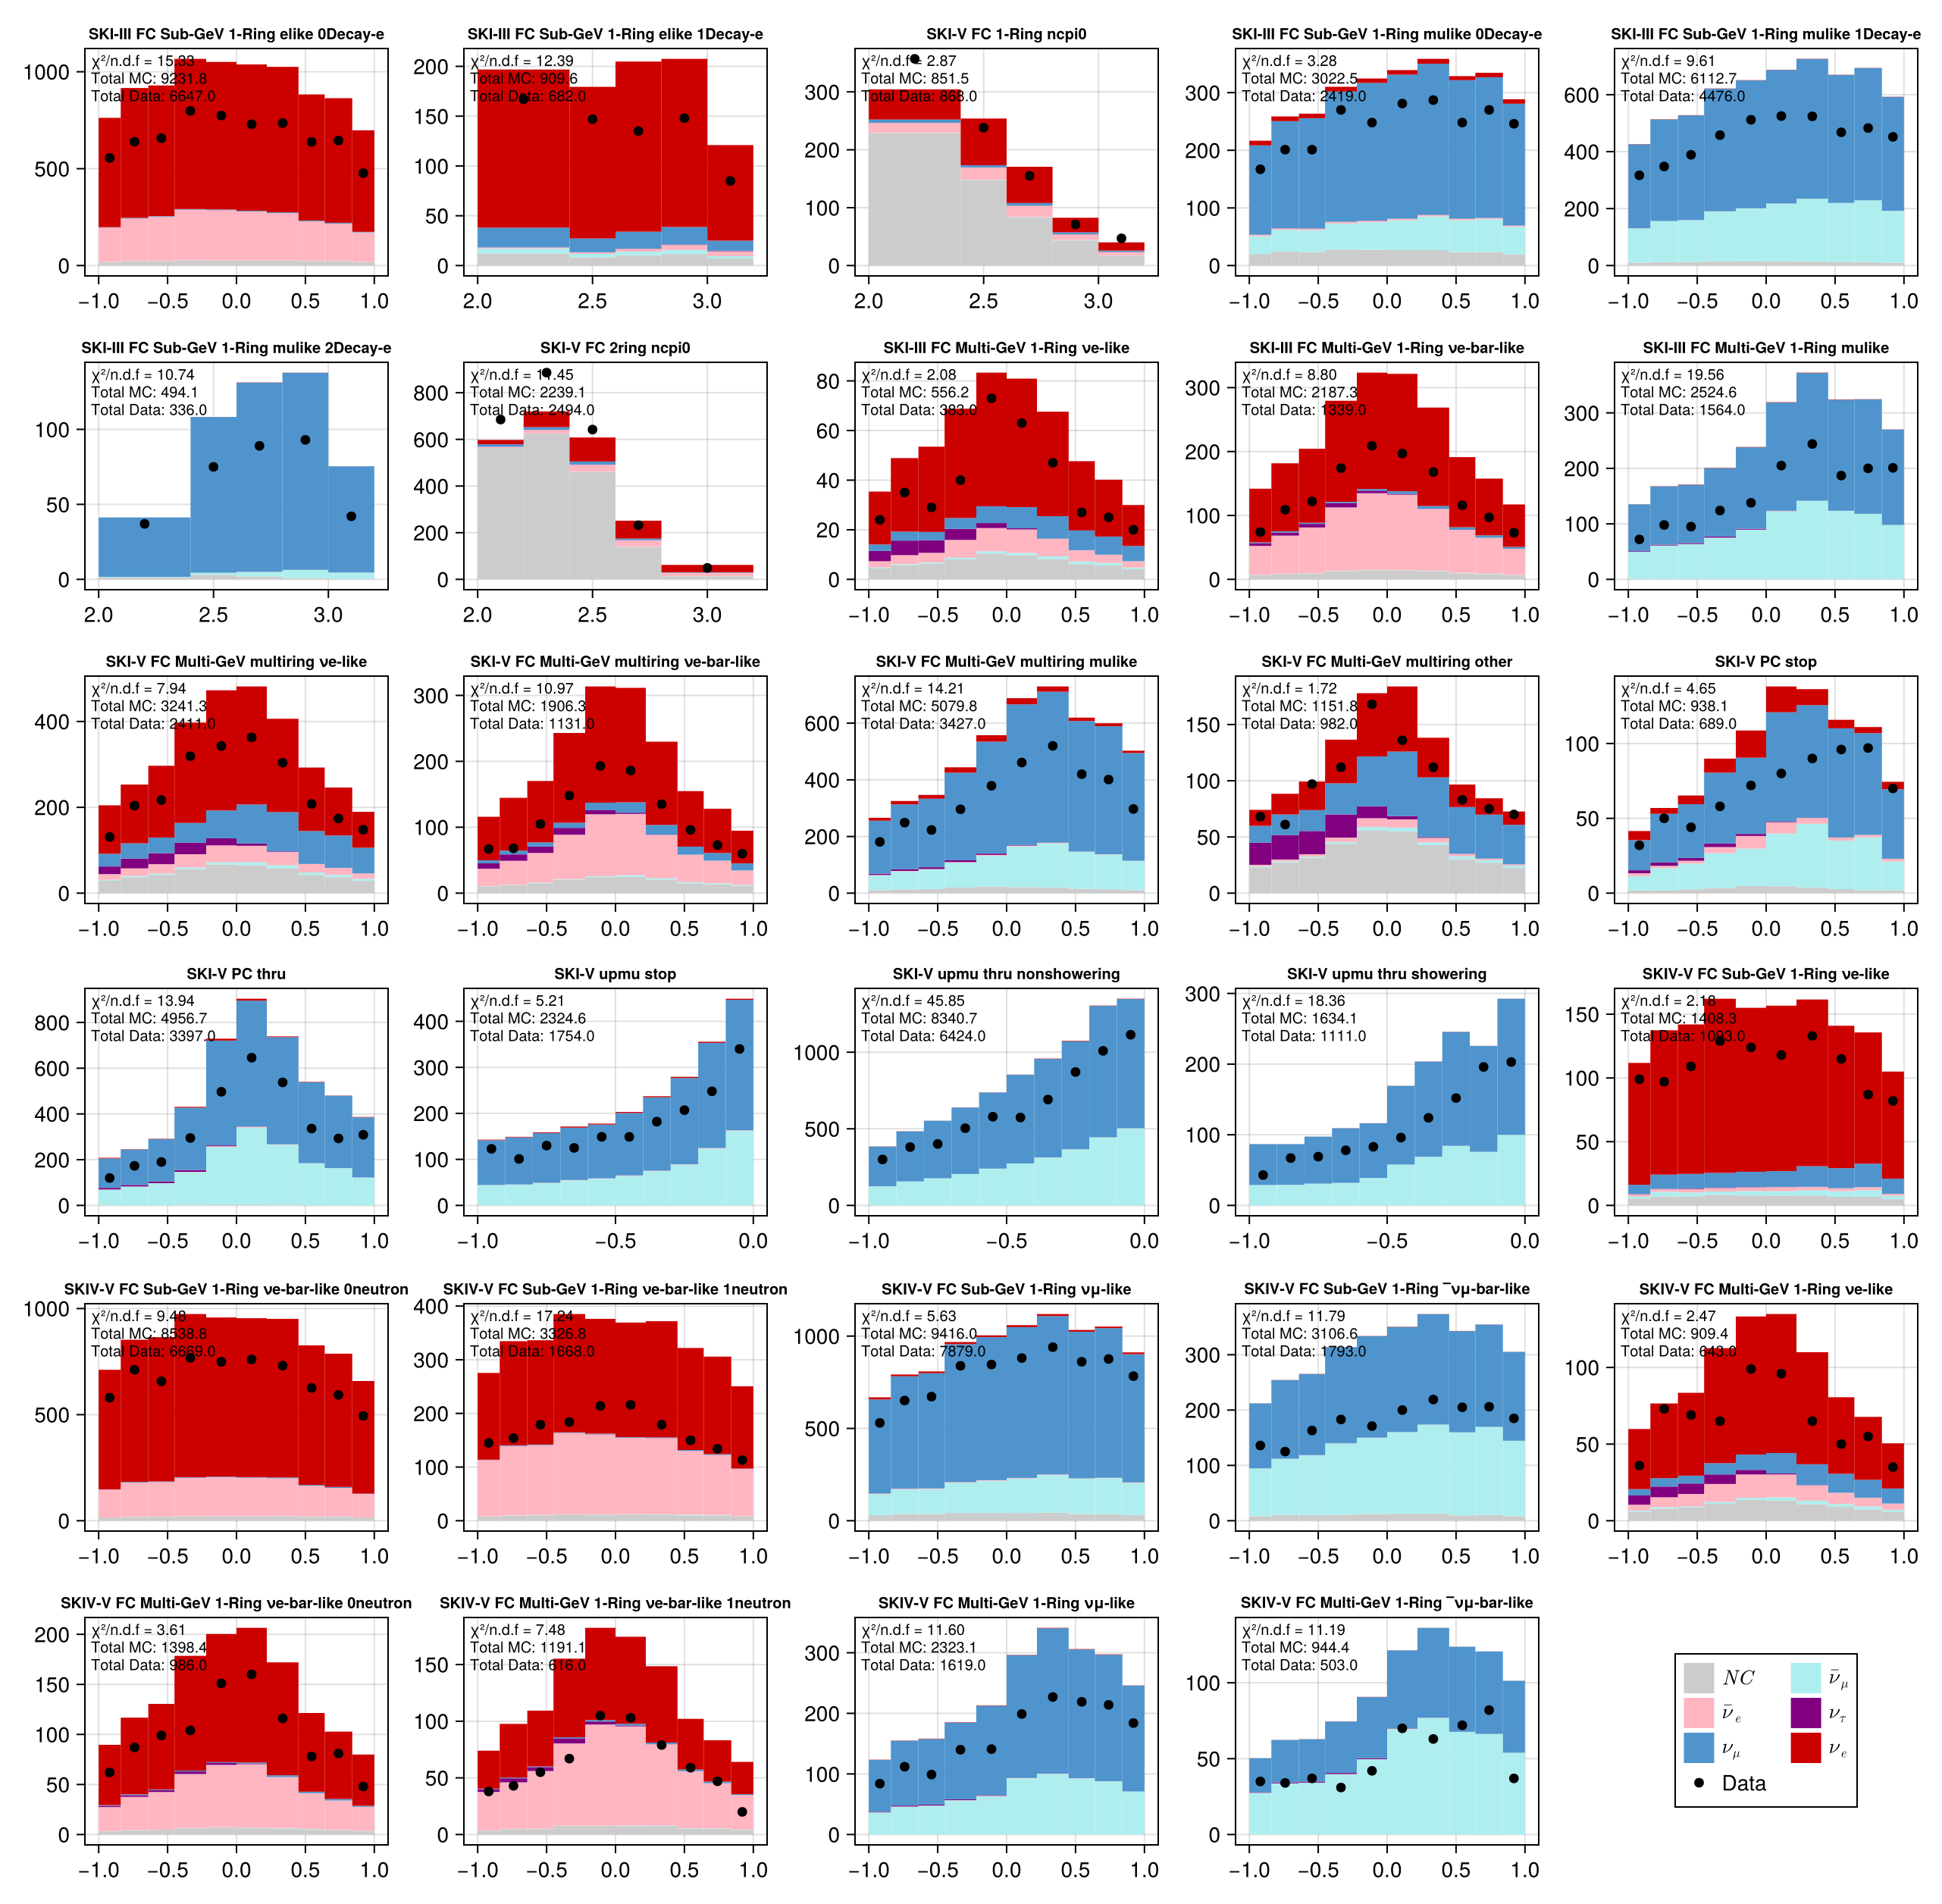

In [146]:
sk.plot(params)

In [51]:
using DensityInterface, BAT, MeasureBase

In [164]:
likelihood = Newtrinos.generate_likelihood((;sk,));

In [53]:
vars_to_scan = OrderedDict()
vars_to_scan[:θ₂₃] = 11
vars_to_scan[:Δm²₃₁] = 11

11

In [149]:
@reset params.Δm²₃₁ = 2.475e-3
@reset params.θ₂₃ = asin(sqrt(0.45))
@reset params.θ₁₃ = asin(sqrt(0.02))
@reset params.δCP = -1.89

(atm_flux_delta_spectral_index = 0.0, atm_flux_nuenuebar_sigma = 0.0, atm_flux_nuenumu_sigma = 0.0, atm_flux_numunumubar_sigma = 0.0, atm_flux_updown_sigma = 0.0, atm_flux_uphorizonzal_sigma = 0.0, cc1p1h_norm = 1.0, cc1pi_norm = 1.0, cc2p2h_norm = 1.0, ccdis_norm = 1.0, ccother_norm = 1.0, nc_norm = 1.0, nutau_cc_norm = 1.0, sk_energy_scale = 1.0, sk_fc_norm = 1.0, sk_fiducial_norm = 1.0, sk_i_iii_decay_e_tag_eff = 1.0, sk_i_v_btd_1 = 1.0, sk_i_v_btd_2 = 1.0, sk_i_v_btd_3 = 1.0, sk_iv_v_decay_e_tag_eff = 1.0, sk_iv_v_multigev_neutron_tag_eff = 1.0, sk_iv_v_subgev_neutron_tag_eff = 1.0, sk_nc_mu_norm = 1.0, sk_pc_norm = 1.0, sk_pc_stopping_vs_througoing = 1.0, sk_upmu_nonshower_vs_shower = 1.0, sk_upmu_norm = 1.0, sk_upmu_stopping_vs_througoing = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.002475, δCP = -1.89, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1418970546041639, θ₂₃ = 0.7353144528166684)

In [150]:
@reset priors.θ₁₂ = params.θ₁₂
@reset priors.Δm²₂₁ = params.Δm²₂₁
@reset priors.δCP = params.δCP
#@reset priors.Δm²₃₁ = params.Δm²₃₁
#@reset priors.θ₂₃ = params.θ₂₃
#@reset priors.θ₁₃ = params.θ₁₃

(atm_flux_delta_spectral_index = Truncated(Normal{Float64}(μ=0.0, σ=0.1); lower=-0.3, upper=0.3), atm_flux_nuenuebar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_nuenumu_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_numunumubar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_updown_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_uphorizonzal_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), cc1p1h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc1pi_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc2p2h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), ccdis_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.1); lower=0.7, upper=1.3), ccother_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.4); lower=0.2, upper=1.8), nc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lo

In [151]:
priors

(atm_flux_delta_spectral_index = Truncated(Normal{Float64}(μ=0.0, σ=0.1); lower=-0.3, upper=0.3), atm_flux_nuenuebar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_nuenumu_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_numunumubar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_updown_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_uphorizonzal_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), cc1p1h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc1pi_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc2p2h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), ccdis_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.1); lower=0.7, upper=1.3), ccother_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.4); lower=0.2, upper=1.8), nc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lo

In [153]:
bestfit_no = Newtrinos.find_mle(likelihood, distprod(;priors...,), params)

┌ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0xff0a63e86542e5ac, 0x85a7cbf84bd42fce, 0xba8d4572e3b43d51, 0xb4f4339ce76a6984, 0x5c5b2afbfc7d68a5, 0xa6f29ea6a32e42ea, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())
└ @ BAT /home/peller/.julia/packages/BAT/yelYL/src/algotypes/bat_context.jl:185
┌ Info: Running Optimization for point  Δm²₂₁: 7.53e-5 δCP: -1.89 θ₁₂: 0.5872523687443223
└ @ Newtrinos /mnt/c/Users/peller/work/Newtrinos/src/analysis/analysis_tools.jl:70


(-3090.9184970784668, -3063.7521746520133, (atm_flux_delta_spectral_index = -0.13879421602183836, atm_flux_nuenuebar_sigma = 1.836392226630818, atm_flux_nuenumu_sigma = -0.4158545529532829, atm_flux_numunumubar_sigma = 0.4512076659728742, atm_flux_updown_sigma = 0.6106268854387676, atm_flux_uphorizonzal_sigma = -0.6879022388946668, cc1p1h_norm = 0.5075583395778822, cc1pi_norm = 1.013922440856694, cc2p2h_norm = 1.599022914352563, ccdis_norm = 1.0232816180768398, ccother_norm = 0.20106438114887526, nc_norm = 1.2587632463982061, nutau_cc_norm = 1.0365972930702334, sk_energy_scale = 0.9814327504819018, sk_fc_norm = 0.9751611964891126, sk_fiducial_norm = 0.9922487555591429, sk_i_iii_decay_e_tag_eff = 0.9854725076764626, sk_i_v_btd_1 = 0.9130052326828608, sk_i_v_btd_2 = 0.9866335198324147, sk_i_v_btd_3 = 0.9810890419540975, sk_iv_v_decay_e_tag_eff = 1.0023673104467112, sk_iv_v_multigev_neutron_tag_eff = 1.0849919192046624, sk_iv_v_subgev_neutron_tag_eff = 1.0913773046025654, sk_nc_mu_norm = 

In [154]:
save(joinpath(@__DIR__, "superk_atm_bestfit_no_with_energyscale.jld2"), "result", bestfit_no)

In [152]:
prior = distprod(;priors...)

NamedTupleDist((atm_flux_delta_spectral_index = Truncated(Normal{Float64}(μ=0.0, σ=0.1); lower=-0.3, upper=0.3), atm_flux_nuenuebar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_nuenumu_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_numunumubar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_updown_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_uphorizonzal_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), cc1p1h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc1pi_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc2p2h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), ccdis_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.1); lower=0.7, upper=1.3), ccother_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.4); lower=0.2, upper=1.8), nc_norm = Truncated(Normal{Float64}(μ=

In [59]:
using FileIO, JLD2

In [62]:
bestfit_no = load(joinpath(@__DIR__, "superk_atm_bestfit.jld2"), "result")

(-3092.626669356174, -3070.0335645222067, (atm_flux_delta_spectral_index = -0.16826472317300636, atm_flux_nuenuebar_sigma = 1.360994190875884, atm_flux_nuenumu_sigma = -0.10669019354599743, atm_flux_numunumubar_sigma = 0.5194727218942162, atm_flux_updown_sigma = 0.551838068701546, atm_flux_uphorizonzal_sigma = -0.5347220725599376, cc1p1h_norm = 0.40017092221571915, cc1pi_norm = 0.8276677663364661, cc2p2h_norm = 1.5999999999999908, ccdis_norm = 0.8872195860344547, ccother_norm = 0.20001917857282348, nc_norm = 1.2854506567355721, nutau_cc_norm = 1.084465820762789, sk_fc_norm = 0.9616933255360456, sk_fiducial_norm = 0.9895417729684755, sk_i_iii_decay_e_tag_eff = 0.9858632347730846, sk_i_v_btd_1 = 0.9164813491191983, sk_i_v_btd_2 = 0.9932520685809139, sk_i_v_btd_3 = 0.9820065969529178, sk_iv_v_decay_e_tag_eff = 1.0034832778844613, sk_iv_v_multigev_neutron_tag_eff = 1.0858814840865976, sk_iv_v_subgev_neutron_tag_eff = 1.0921531008861185, sk_nc_mu_norm = 1.035647205188834, sk_pc_norm = 0.971

In [66]:
priors

(atm_flux_delta_spectral_index = Truncated(Normal{Float64}(μ=0.0, σ=0.1); lower=-0.3, upper=0.3), atm_flux_nuenuebar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_nuenumu_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_numunumubar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_updown_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_uphorizonzal_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), cc1p1h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc1pi_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc2p2h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), ccdis_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.1); lower=0.7, upper=1.3), ccother_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.4); lower=0.2, upper=1.8), nc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lo

In [67]:
priors_io = @set priors.Δm²₃₁ = Uniform(-0.003, -0.002)

(atm_flux_delta_spectral_index = Truncated(Normal{Float64}(μ=0.0, σ=0.1); lower=-0.3, upper=0.3), atm_flux_nuenuebar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_nuenumu_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_numunumubar_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_updown_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), atm_flux_uphorizonzal_sigma = Truncated(Normal{Float64}(μ=0.0, σ=1.0); lower=-3.0, upper=3.0), cc1p1h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc1pi_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), cc2p2h_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.4, upper=1.6), ccdis_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.1); lower=0.7, upper=1.3), ccother_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.4); lower=0.2, upper=1.8), nc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lo

In [69]:
params_io = (@set bestfit_no[3].Δm²₃₁ = -2.475e-3)[3]

(atm_flux_delta_spectral_index = -0.16826472317300636, atm_flux_nuenuebar_sigma = 1.360994190875884, atm_flux_nuenumu_sigma = -0.10669019354599743, atm_flux_numunumubar_sigma = 0.5194727218942162, atm_flux_updown_sigma = 0.551838068701546, atm_flux_uphorizonzal_sigma = -0.5347220725599376, cc1p1h_norm = 0.40017092221571915, cc1pi_norm = 0.8276677663364661, cc2p2h_norm = 1.5999999999999908, ccdis_norm = 0.8872195860344547, ccother_norm = 0.20001917857282348, nc_norm = 1.2854506567355721, nutau_cc_norm = 1.084465820762789, sk_fc_norm = 0.9616933255360456, sk_fiducial_norm = 0.9895417729684755, sk_i_iii_decay_e_tag_eff = 0.9858632347730846, sk_i_v_btd_1 = 0.9164813491191983, sk_i_v_btd_2 = 0.9932520685809139, sk_i_v_btd_3 = 0.9820065969529178, sk_iv_v_decay_e_tag_eff = 1.0034832778844613, sk_iv_v_multigev_neutron_tag_eff = 1.0858814840865976, sk_iv_v_subgev_neutron_tag_eff = 1.0921531008861185, sk_nc_mu_norm = 1.035647205188834, sk_pc_norm = 0.9713349165814095, sk_pc_stopping_vs_througoin

In [70]:
bestfit_io = Newtrinos.find_mle(likelihood, distprod(;priors_io...,), params_io)

┌ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xff0a63e86542e5ac, 0x85a7cbf84bd42fce, 0xba8d4572e3b43d51, 0xb4f4339ce76a6984, 0x5c5b2afbfc7d68a5, 0xa6f29ea6a32e42ea, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), ADTypes.NoAutoDiff())
└ @ BAT /home/peller/.julia/packages/BAT/yelYL/src/algotypes/bat_context.jl:152
┌ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0xff0a63e86542e5ac, 0x85a7cbf84bd42fce, 0xba8d4572e3b43d51, 0xb4f4339ce76a6984, 0x5c5b2afbfc7d68a5, 0xa6f29ea6a32e42ea, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())
└ @ BAT /home/peller/.julia/packages/BAT/yelYL/src/algotypes/bat_context.jl:185
┌ Info: Running Optimization for point  Δm²₂₁: 7.53e-5 δCP: -1.89 θ₁₂: 0.5872523687443223
└ @ Newtrinos /mnt/c/Users/peller/work/Newtrinos/src/an

(-3093.0336905704644, -3070.7241476256286, (atm_flux_delta_spectral_index = -0.17057098924572944, atm_flux_nuenuebar_sigma = 1.5342168971361267, atm_flux_nuenumu_sigma = -0.16079802938783733, atm_flux_numunumubar_sigma = 0.7154593835108519, atm_flux_updown_sigma = 0.7474692045554179, atm_flux_uphorizonzal_sigma = -0.2877027159202916, cc1p1h_norm = 0.4002169387044806, cc1pi_norm = 0.7755818344740733, cc2p2h_norm = 1.5999999999999908, ccdis_norm = 0.8901942391814897, ccother_norm = 0.20001884250131052, nc_norm = 1.265974658769487, nutau_cc_norm = 1.0831093915846794, sk_fc_norm = 0.9701431001738623, sk_fiducial_norm = 0.9908175197283418, sk_i_iii_decay_e_tag_eff = 0.9852094731195375, sk_i_v_btd_1 = 0.9112391643851818, sk_i_v_btd_2 = 0.9906153099050828, sk_i_v_btd_3 = 0.9816059430278502, sk_iv_v_decay_e_tag_eff = 1.0031175227319102, sk_iv_v_multigev_neutron_tag_eff = 1.0878136887591332, sk_iv_v_subgev_neutron_tag_eff = 1.0925192387162561, sk_nc_mu_norm = 0.9725165257215729, sk_pc_norm = 0.

In [71]:
save(joinpath(@__DIR__, "superk_atm_bestfit_io.jld2"), "result", bestfit_io)

In [484]:
bestfit_restricted = Newtrinos.find_mle(likelihood, prior, params)

(-3100.7024532867413, -3085.190513260989, (atm_flux_delta_spectral_index = -0.16552450912796285, atm_flux_nuenumu_sigma = 0.524672887307823, atm_flux_nunubar_sigma = 0.9294877693558414, atm_flux_uphorizonzal_sigma = -0.4896540316289074, cc1p1h_norm = 0.40000773362548925, cc1pi_norm = 0.8429040862787841, cc2p2h_norm = 1.5999999999999908, ccdis_norm = 0.8750749636977785, ccother_norm = 0.20000263721732525, nc_norm = 1.283477077526498, nutau_cc_norm = 1.0969235630810865, sk_fc_norm = 0.9651647483925812, sk_fiducial_norm = 0.9917547094412709, sk_i_iii_decay_e_tag_eff = 0.9864360932553367, sk_i_v_btd_1 = 0.9186023743006938, sk_i_v_btd_2 = 0.9982815681952131, sk_i_v_btd_3 = 0.9819714525501578, sk_iv_v_decay_e_tag_eff = 1.0042593823187993, sk_iv_v_multigev_neutron_tag_eff = 1.0858202854115886, sk_iv_v_subgev_neutron_tag_eff = 1.092563148852174, sk_nc_mu_norm = 1.0790064824937344, sk_pc_norm = 0.9822112991520456, sk_pc_stopping_vs_througoing = 1.0155882459019432, sk_upmu_nonshower_vs_shower = 

In [156]:
sk_chi2(e, o) = 2*sum((e .- o .+ o.*replace(log.(o ./ e), -Inf=>0)))

sk_chi2 (generic function with 1 method)

In [584]:
sk_chi2(mean(sk.forward_model(params)), sk.assets.observed)

2251.2177618153114

In [157]:
sk_chi2(mean(sk.forward_model(bestfit_no[3])), sk.assets.observed)

1020.1612541069851

In [581]:
sk_chi2(mean(sk.forward_model(bestfit_si[3])), sk.assets.observed)

1023.577598662391

target: chi2 = 1022

In [521]:
bestfit_si = Newtrinos.find_mle(likelihood, prior, bestfit[3])

(-3092.626669356174, -3070.0335645222067, (atm_flux_delta_spectral_index = -0.16826472317300636, atm_flux_nuenuebar_sigma = 1.360994190875884, atm_flux_nuenumu_sigma = -0.10669019354599743, atm_flux_numunumubar_sigma = 0.5194727218942162, atm_flux_updown_sigma = 0.551838068701546, atm_flux_uphorizonzal_sigma = -0.5347220725599376, cc1p1h_norm = 0.40017092221571915, cc1pi_norm = 0.8276677663364661, cc2p2h_norm = 1.5999999999999908, ccdis_norm = 0.8872195860344547, ccother_norm = 0.20001917857282348, nc_norm = 1.2854506567355721, nutau_cc_norm = 1.084465820762789, sk_fc_norm = 0.9616933255360456, sk_fiducial_norm = 0.9895417729684755, sk_i_iii_decay_e_tag_eff = 0.9858632347730846, sk_i_v_btd_1 = 0.9164813491191983, sk_i_v_btd_2 = 0.9932520685809139, sk_i_v_btd_3 = 0.9820065969529178, sk_iv_v_decay_e_tag_eff = 1.0034832778844613, sk_iv_v_multigev_neutron_tag_eff = 1.0858814840865976, sk_iv_v_subgev_neutron_tag_eff = 1.0921531008861185, sk_nc_mu_norm = 1.035647205188834, sk_pc_norm = 0.971

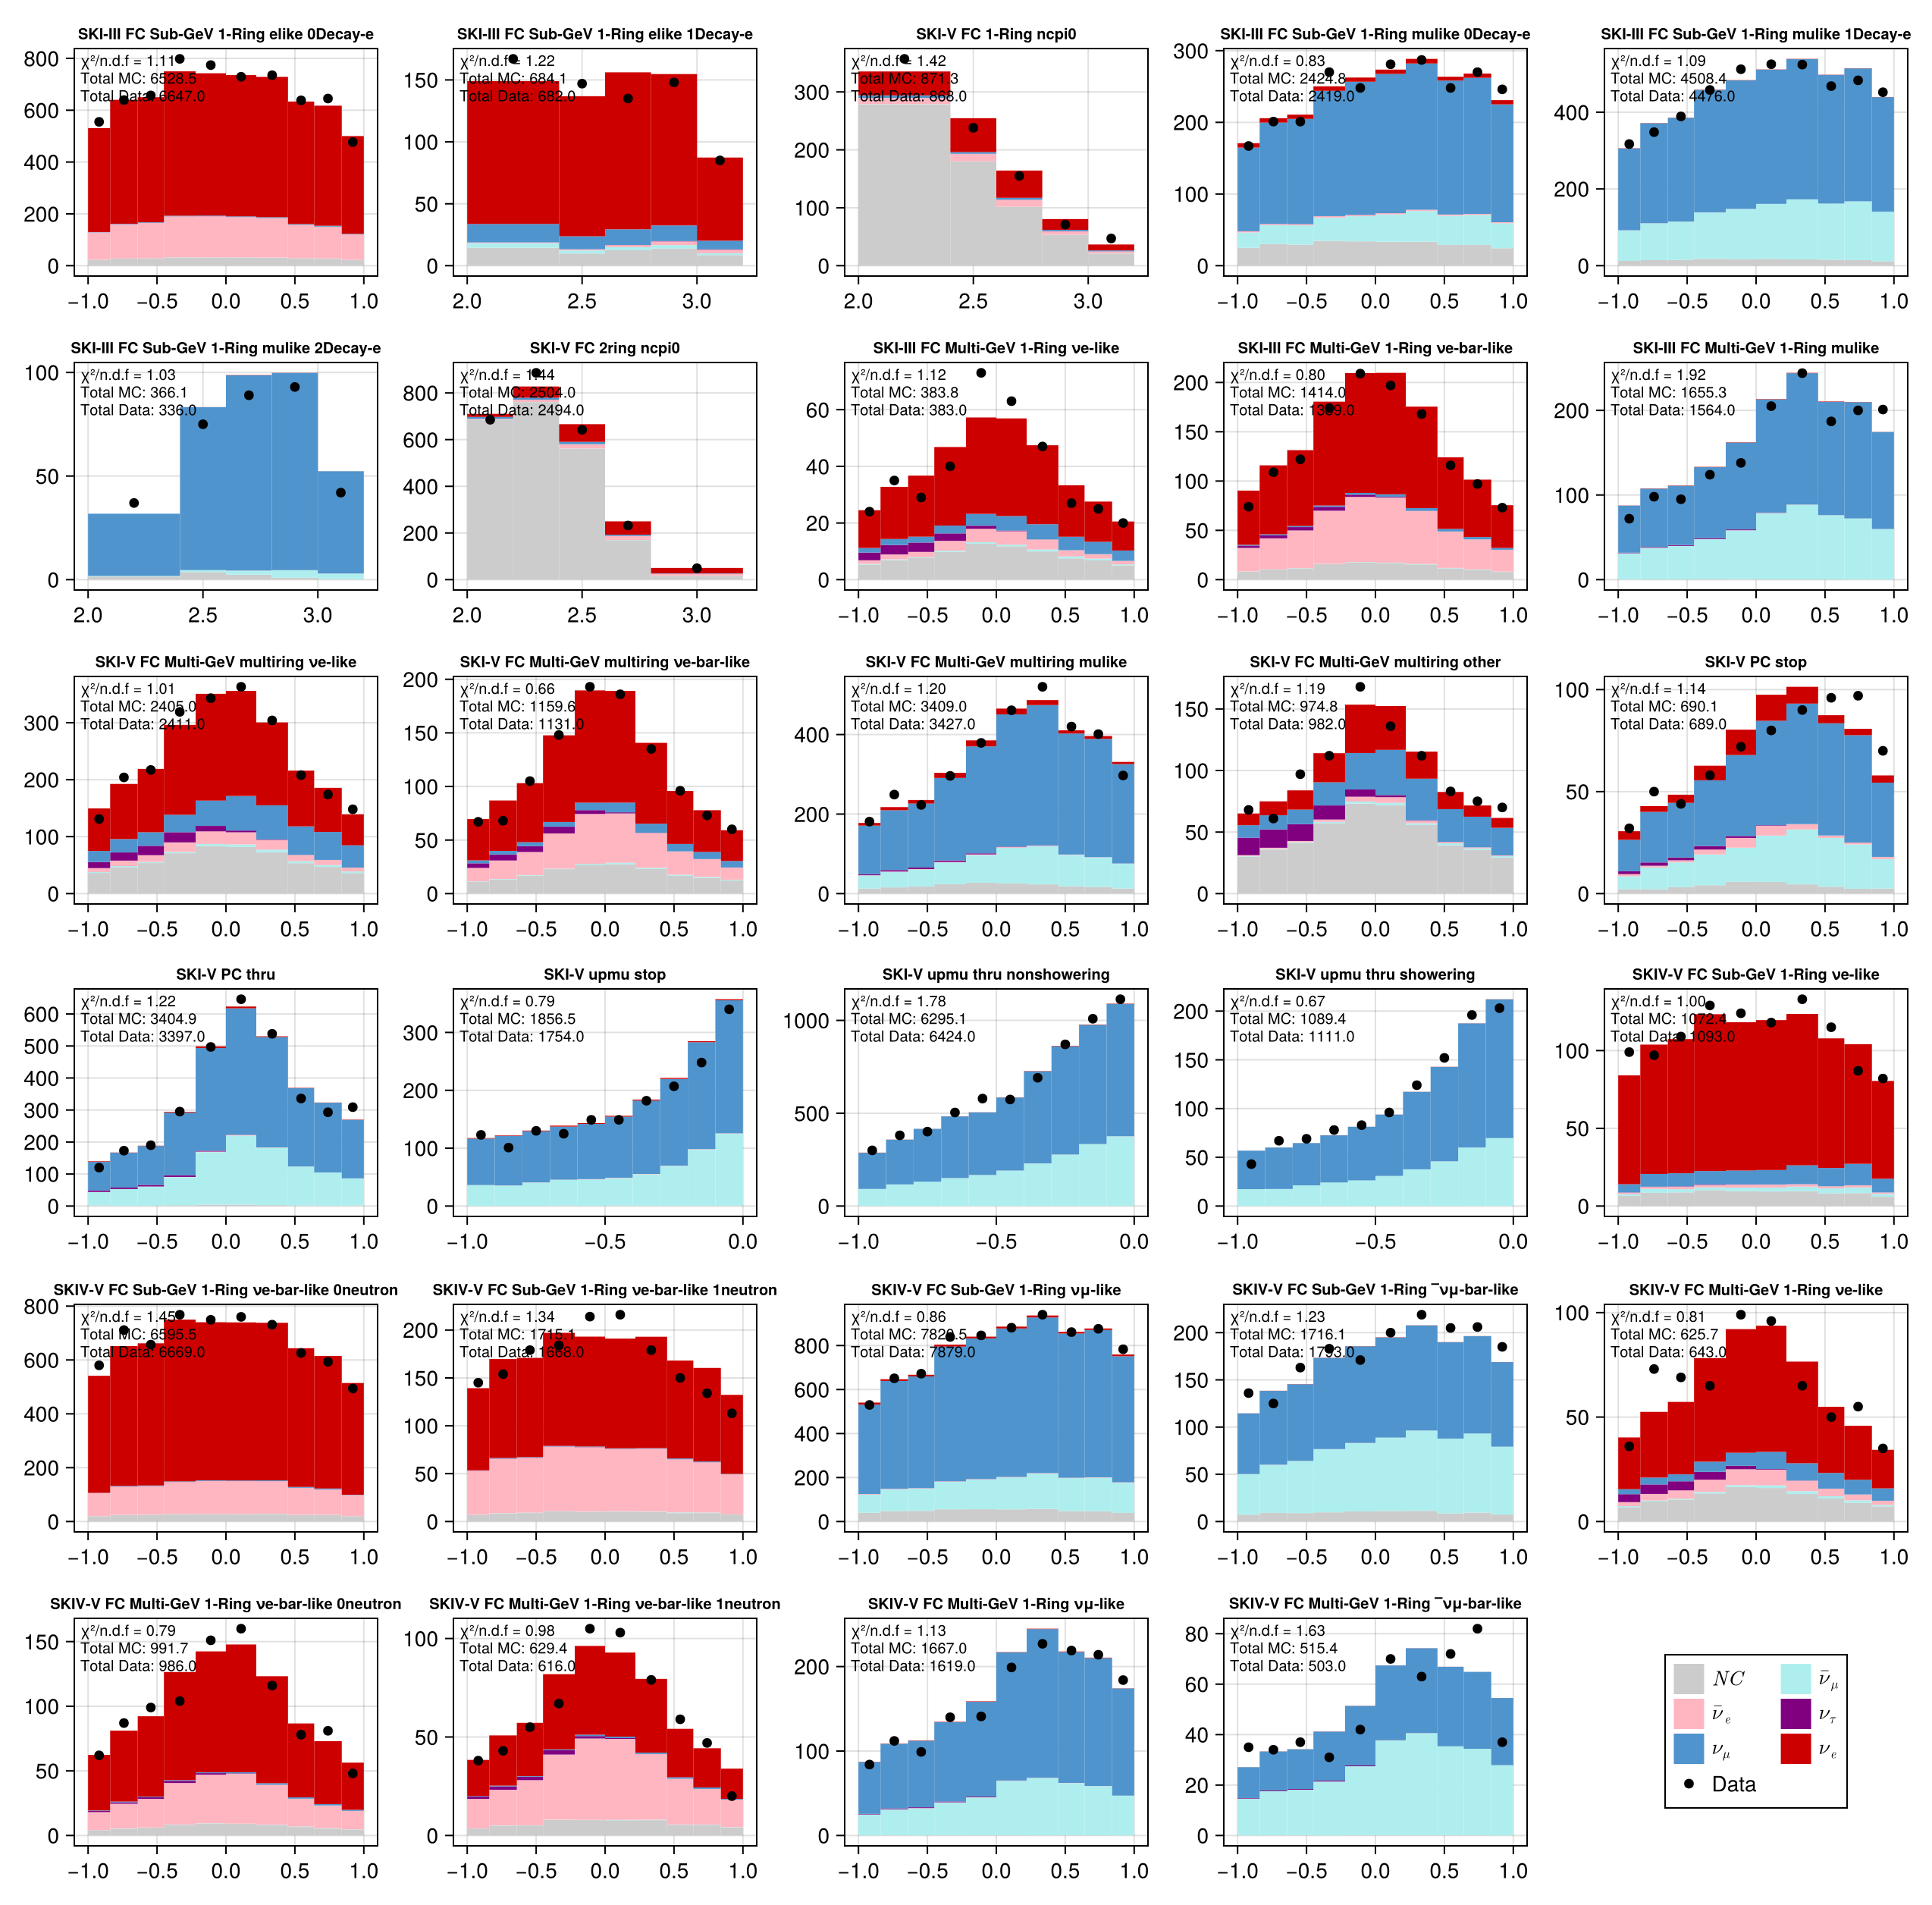

In [158]:
sk.plot(bestfit_no[3])

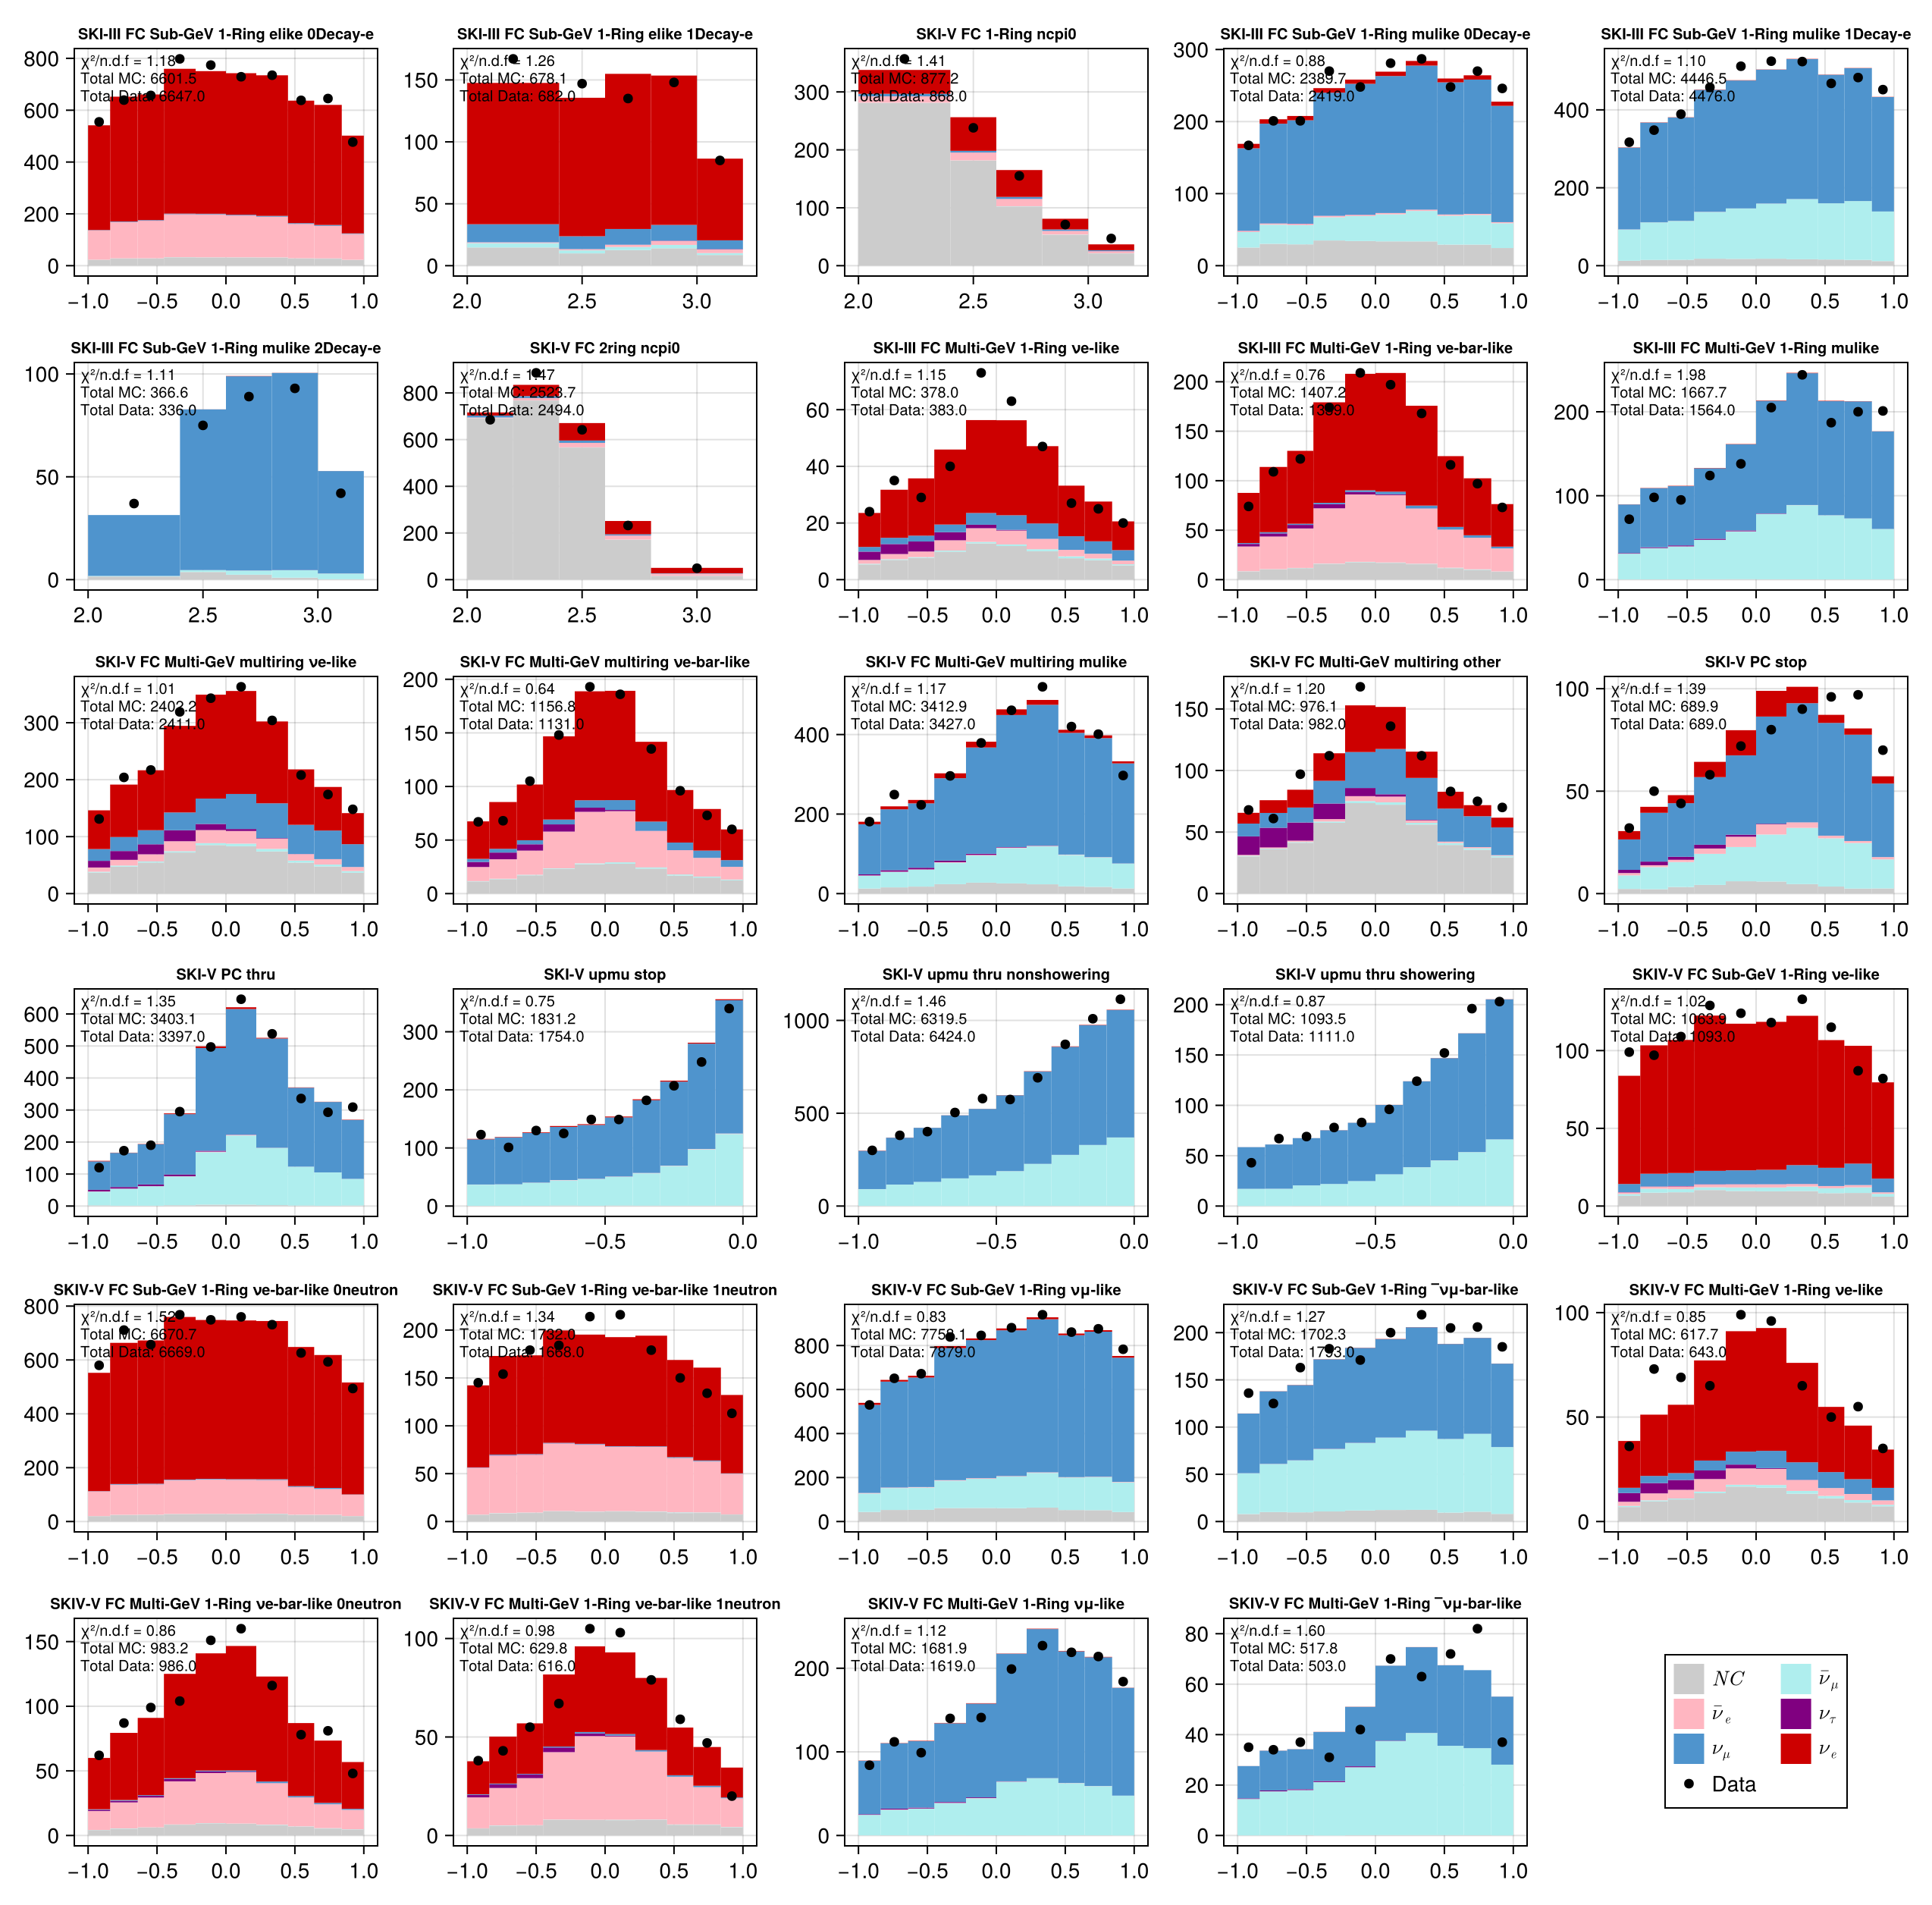

In [488]:
sk.plot(bestfit_restricted[3])

In [503]:
keys(bestfit[3])

(:atm_flux_delta_spectral_index, :atm_flux_nuenuebar_sigma, :atm_flux_nuenumu_sigma, :atm_flux_numunumubar_sigma, :atm_flux_updown_sigma, :atm_flux_uphorizonzal_sigma, :cc1p1h_norm, :cc1pi_norm, :cc2p2h_norm, :ccdis_norm, :ccother_norm, :nc_norm, :nutau_cc_norm, :sk_fc_norm, :sk_fiducial_norm, :sk_i_iii_decay_e_tag_eff, :sk_i_v_btd_1, :sk_i_v_btd_2, :sk_i_v_btd_3, :sk_iv_v_decay_e_tag_eff, :sk_iv_v_multigev_neutron_tag_eff, :sk_iv_v_subgev_neutron_tag_eff, :sk_nc_mu_norm, :sk_pc_norm, :sk_pc_stopping_vs_througoing, :sk_upmu_nonshower_vs_shower, :sk_upmu_norm, :sk_upmu_stopping_vs_througoing, :Δm²₂₁, :Δm²₃₁, :δCP, :θ₁₂, :θ₁₃, :θ₂₃)

In [525]:
sin(bestfit_si[3].θ₂₃)^2

0.46461213706142734

In [527]:
bestfit_si[3].Δm²₃₁ - bestfit_si[3].Δm²₂₁

0.002255569149809885

In [64]:
sk_90pc_sin2_23_dm32 = CSV.read(joinpath(@__DIR__,"90pc_official.csv"), DataFrame; delim=',', ignorerepeated=true, comment="#", header=false);

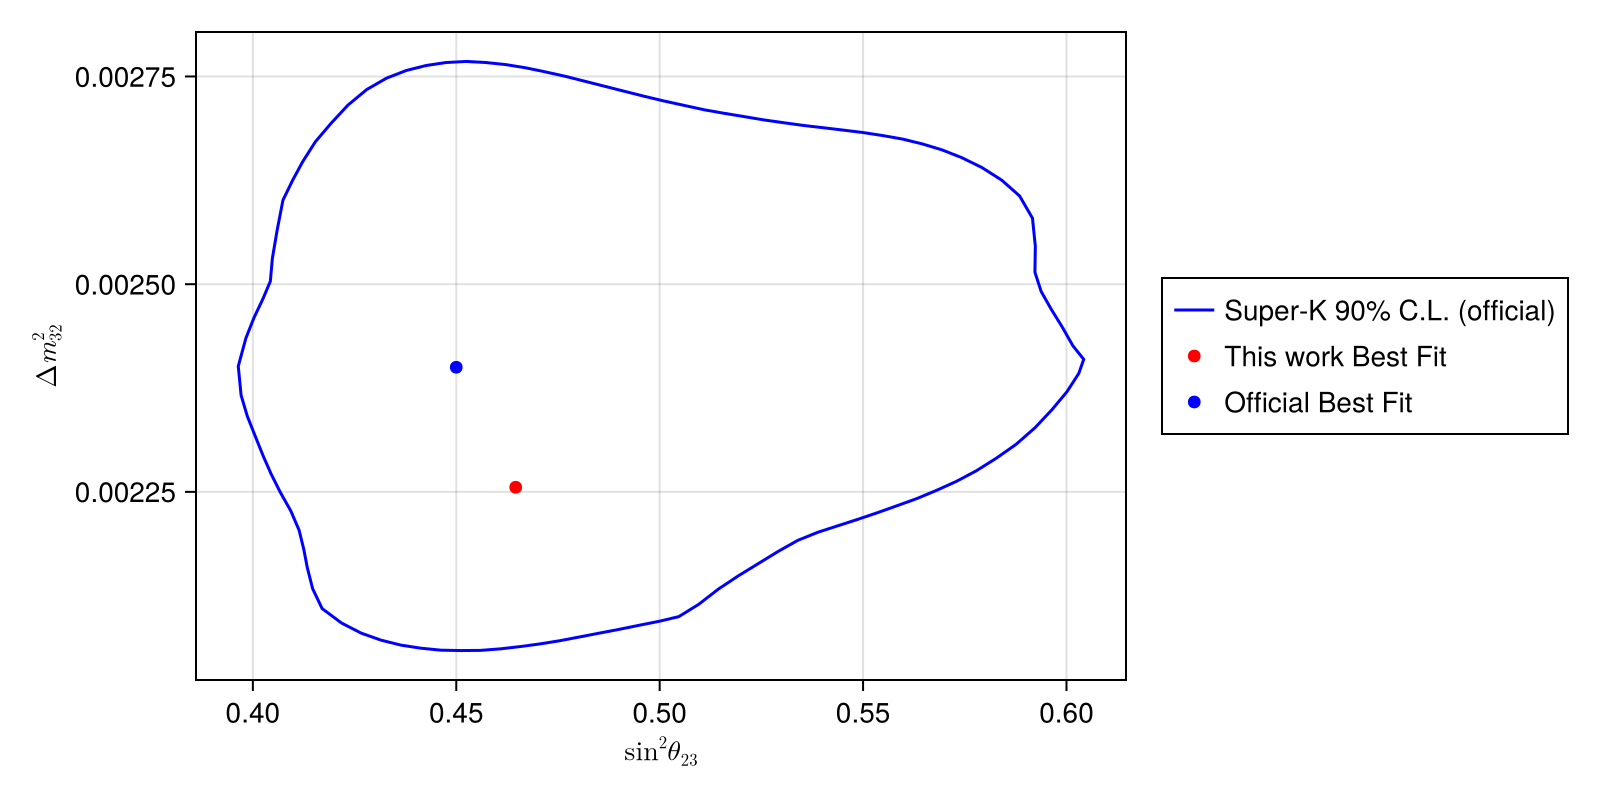

In [65]:
fig = Figure(size=(800,400))
ax = Axis(fig[1,1]; xlabel=L"\sin^2\theta_{23}", ylabel=L"\Delta m^2_{32}")
mask = sk_90pc_sin2_23_dm32.Column2 .> 2.4

sorted_sin2_23 = vcat(sk_90pc_sin2_23_dm32.Column1[mask], reverse(sk_90pc_sin2_23_dm32.Column1[.!mask]), sk_90pc_sin2_23_dm32.Column1[mask][[1]])
sorted_dm32 = vcat(sk_90pc_sin2_23_dm32.Column2[mask], reverse(sk_90pc_sin2_23_dm32.Column2[.!mask]), sk_90pc_sin2_23_dm32.Column2[mask][[1]])*1e-3
lines!(ax, sorted_sin2_23, sorted_dm32; color=:blue, label="Super-K 90% C.L. (official)")
scatter!(ax, [sin(bestfit_no[3].θ₂₃)^2], [bestfit_no[3].Δm²₃₁ - bestfit_no[3].Δm²₂₁]; color=:red, label="This work Best Fit")
scatter!(ax, [0.45], [0.0024]; color=:blue, label="Official Best Fit")
Legend(fig[1,2], ax; position=:rb)
resize_to_layout!(fig)
fig

In [56]:
params

(atm_flux_delta_spectral_index = 0.0, atm_flux_nuenumu_sigma = 0.0, atm_flux_nunubar_sigma = 0.0, atm_flux_uphorizonzal_sigma = 0.0, nc_norm = 1.0, nutau_cc_norm = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [74]:
using ForwardDiff

In [167]:
logdensityof(likelihood, params)

-3706.4467509326273

In [168]:
f(p) = logdensityof(likelihood, p)

f (generic function with 1 method)

In [170]:
gradient = ForwardDiff.gradient(f, params)

(atm_flux_delta_spectral_index = -10465.429902822629, atm_flux_nuenuebar_sigma = 21.20484745426289, atm_flux_nuenumu_sigma = 3.290580434484587, atm_flux_numunumubar_sigma = 17.188138217890952, atm_flux_updown_sigma = 7.4149274373825245, atm_flux_uphorizonzal_sigma = 24.52893203549014, cc1p1h_norm = 1643.1395835107542, cc1pi_norm = 1151.4500933761362, cc2p2h_norm = 285.52075666641076, ccdis_norm = 612.0673397842238, ccother_norm = 52.73642061254048, nc_norm = 688.0864507031746, nutau_cc_norm = 23.531521998575208, sk_energy_scale = 19899.383437365228, sk_fc_norm = 2981.7766275605472, sk_fiducial_norm = 3104.065519671046, sk_i_iii_decay_e_tag_eff = -253.19394549884646, sk_i_v_btd_1 = -225.45727031502648, sk_i_v_btd_2 = 166.12384269373047, sk_i_v_btd_3 = -408.38353095674046, sk_iv_v_decay_e_tag_eff = 197.71895351359152, sk_iv_v_multigev_neutron_tag_eff = 640.0975703102246, sk_iv_v_subgev_neutron_tag_eff = 4694.843570330428, sk_nc_mu_norm = 37.54924797229733, sk_pc_norm = 122.28889211049919

In [82]:
length(params) * 0.5

17.0

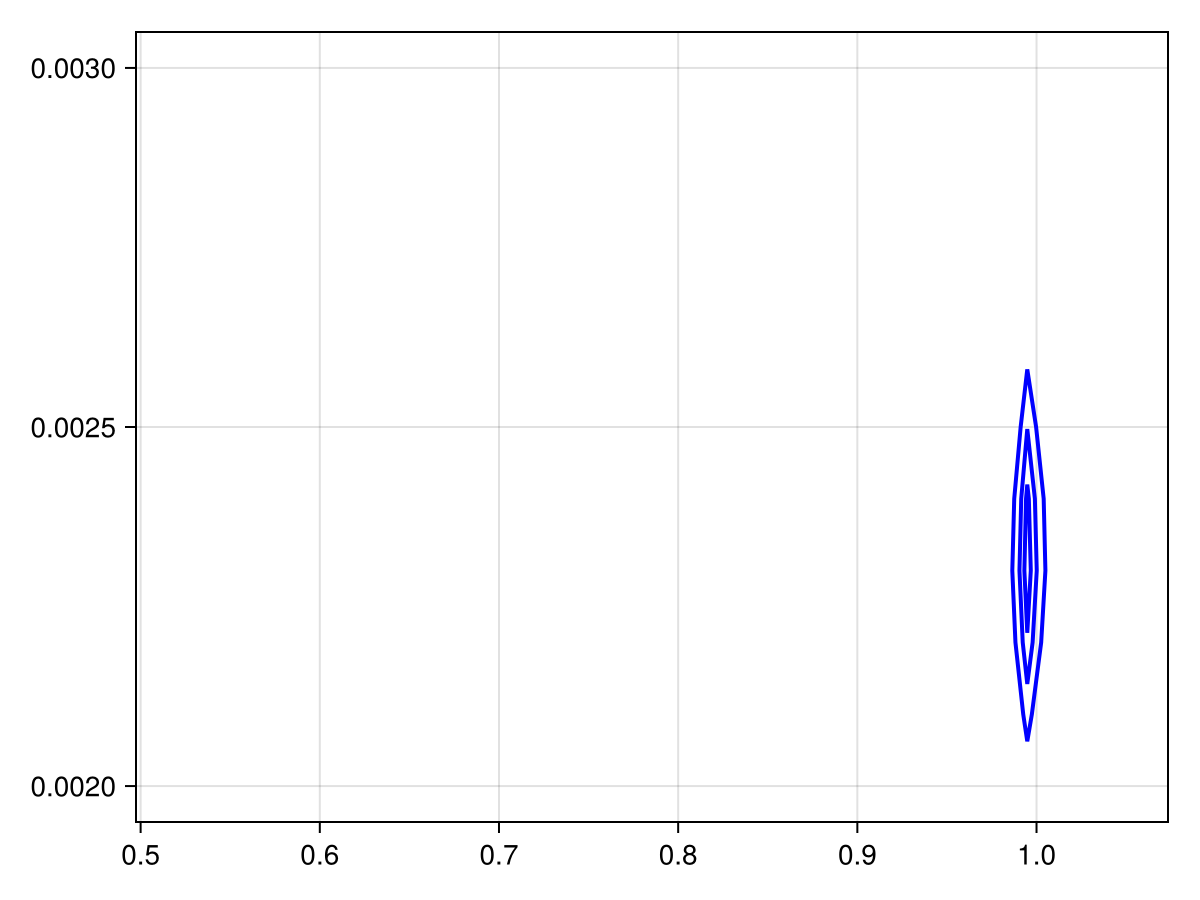

In [84]:
plot(result)

In [86]:
using FileIO

In [87]:
save("sk_atm_2023_profile_result.jld2", Dict("result"=>result))